# Week 1

## Model Simulation and Behaviour

## Task 1.1.

In [1]:
import models
import numpy as np
import matplotlib.pyplot as plt
import datavis as dv


# construct a model from each of the two provided classes
ramp = models.RampModel(beta=0.5, sigma=0.2)
step = models.StepModel(m=500, r=10, x0=.2, Rh=50, isi_gamma_shape=None, Rl=None, dt=None)

## Ramp Model

In [ ]:
dv.rampRasterPlot()
dv.rampWalkPlot()

## Step Model

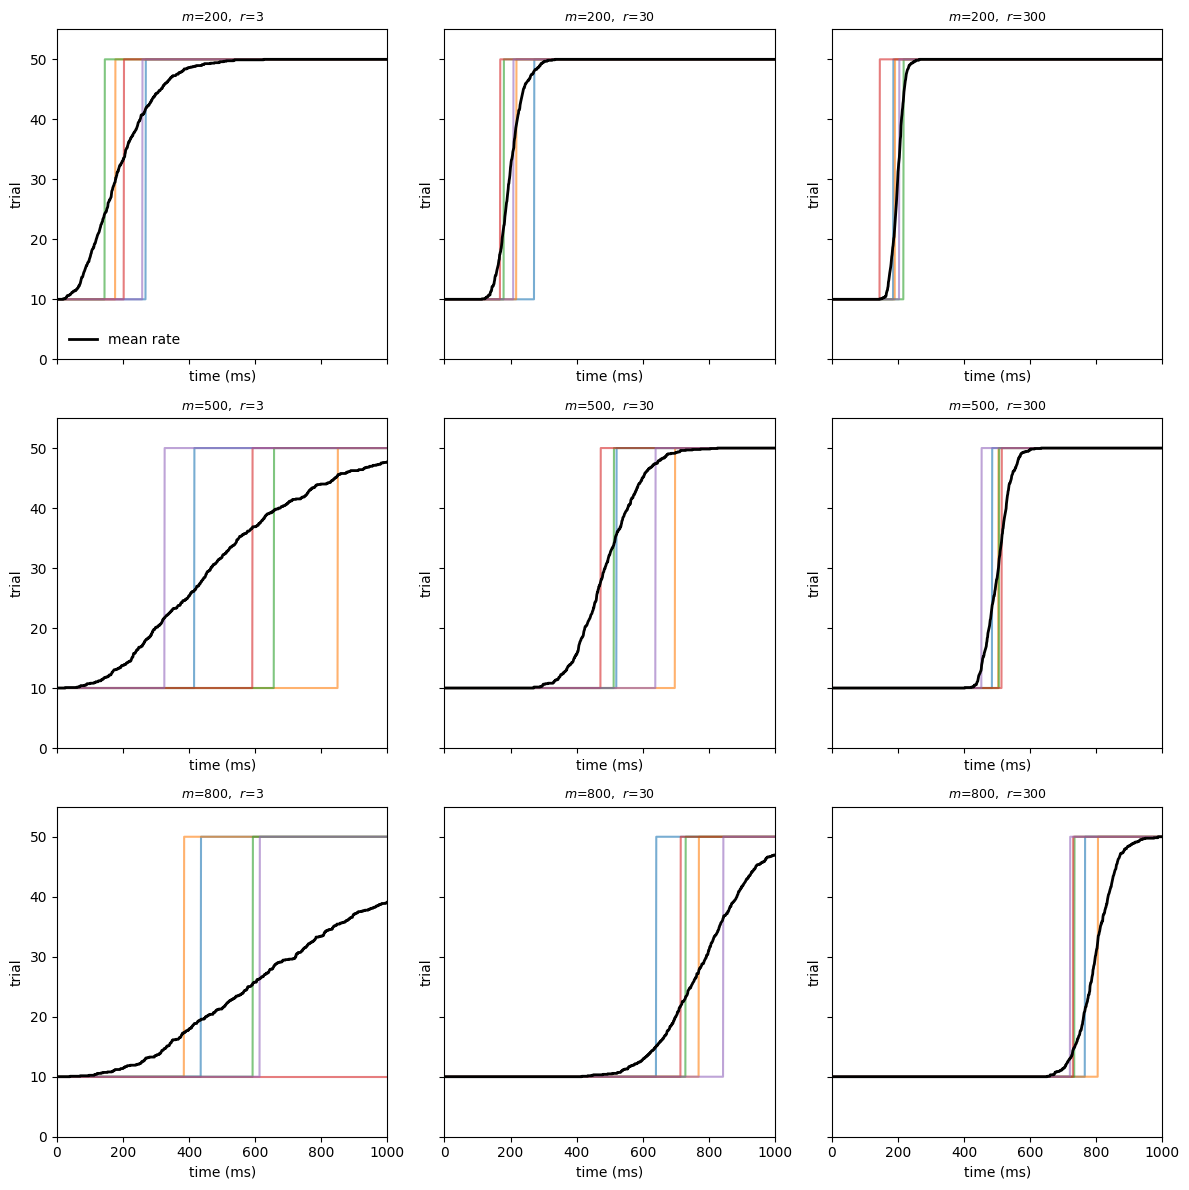

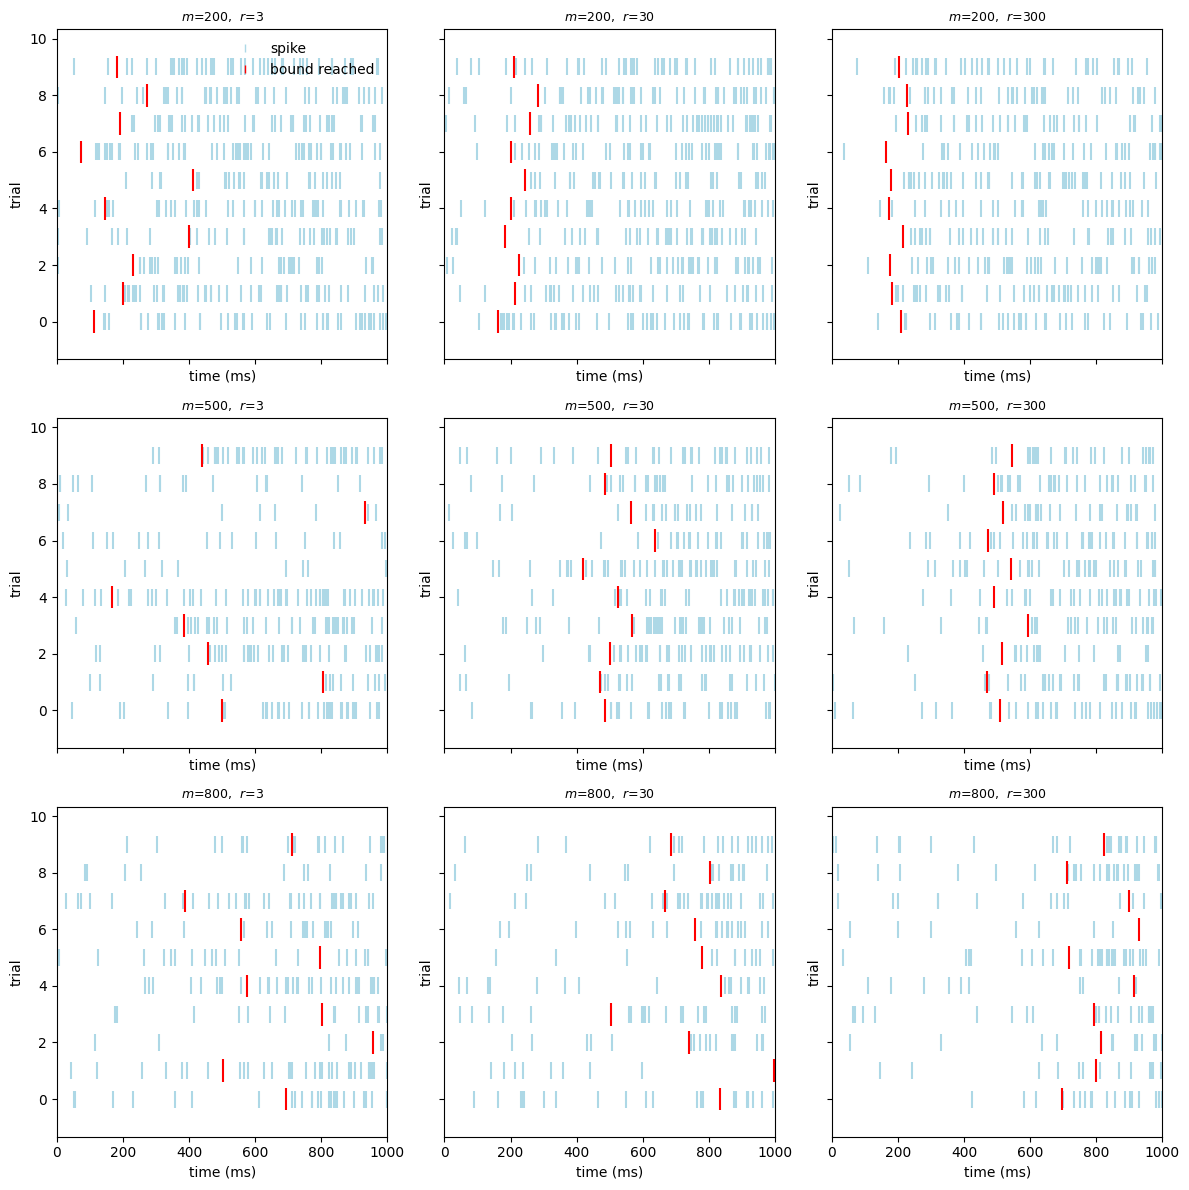

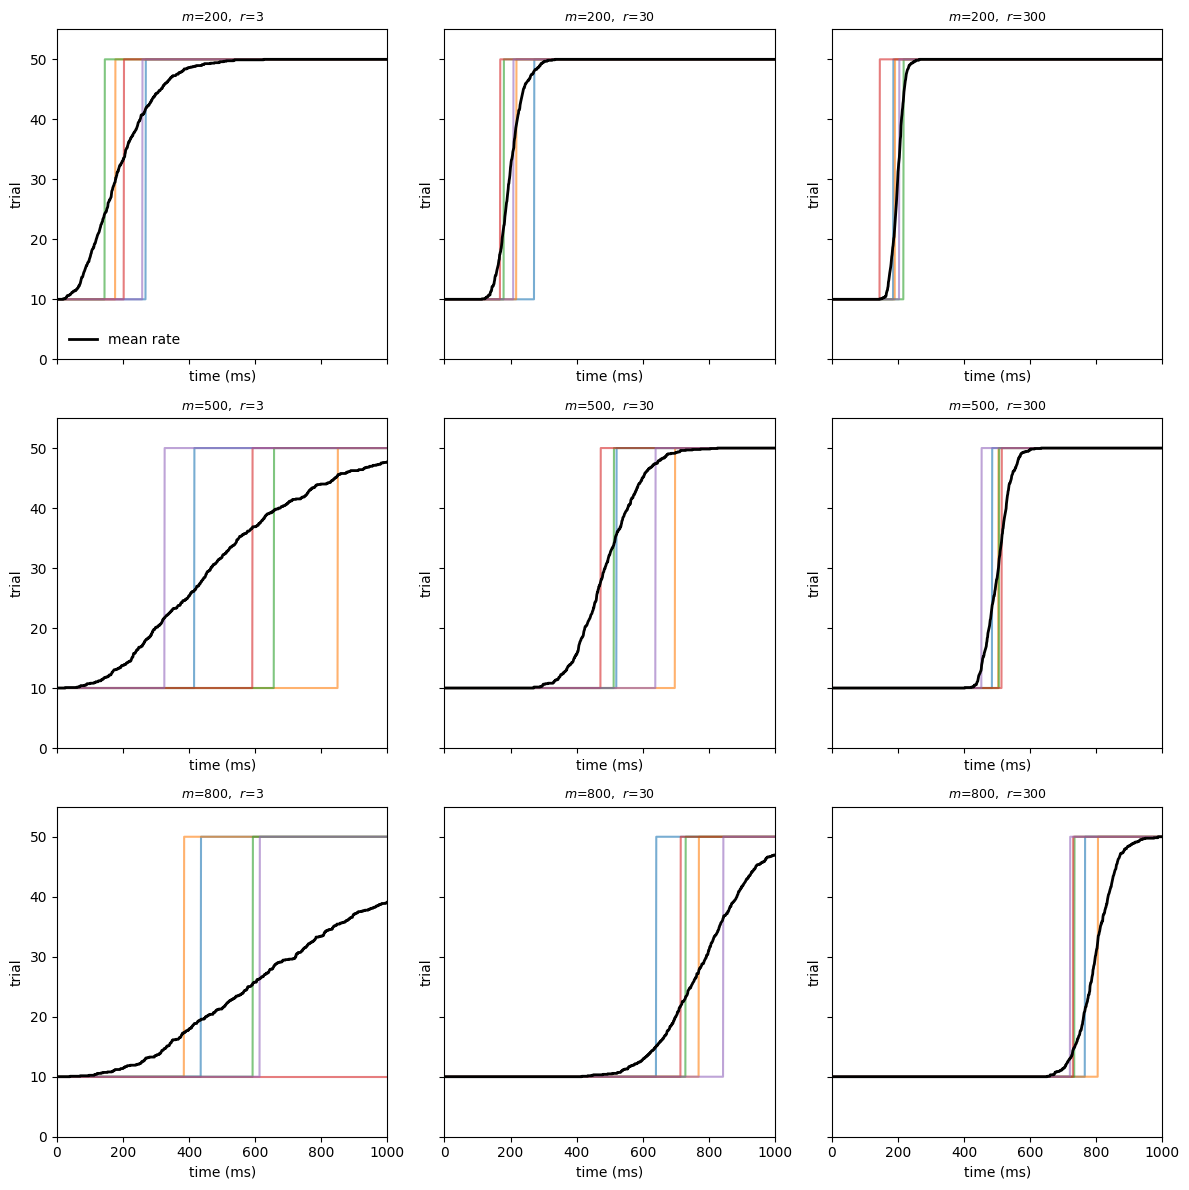

In [12]:
dv.stepRasterPlot()
dv.stepWalkPlot()

## Task 1.2.

In [ ]:
# A) basic PSTH grids
dv.psth_grid(models.RampModel, [0.3,1,3], [0.05,.15,.3], "β", "σ",
          n_trials=200, bin_width=20, smooth_ms=20)
dv.psth_grid(models.StepModel, [200,500,800], [3,30,300], "m", "r",
          n_trials=200, bin_width=20, smooth_ms=20)
plt.show()

# C) trial-count dependence
Ns, errs = dv.psth_variability(models.RampModel, dict(beta=1, sigma=.15))
plt.figure(); plt.loglog(Ns, errs, marker='o');
plt.xlabel("number of trials"); plt.ylabel("avg PSTH SD (Hz)");
plt.title("Ramp β=1 σ=.15  –  PSTH variability"); plt.grid(True, which='both'); plt.show()

# D) Overlay to hunt for matching PSTHs
dv.overlay_psth_comparison(dict(beta=0.8, sigma=.2),
                        dict(m=400, r=20),
                        n_trials=400, bin_width=20, smooth_ms=20)
plt.show()


## Task 1.3.

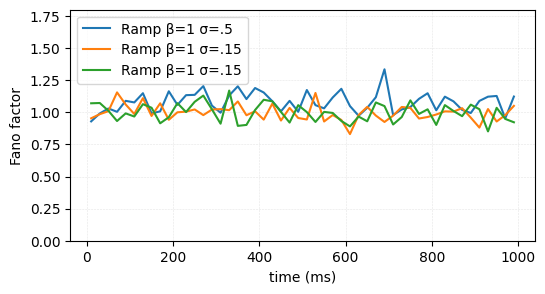

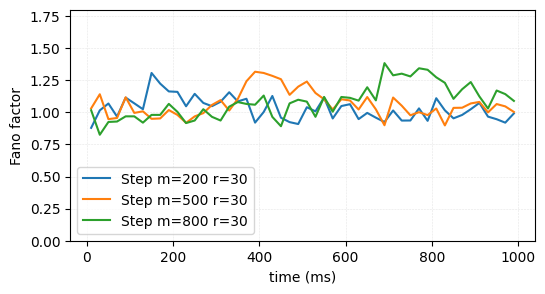

In [10]:
# Fano factor for one parameter set
fig, ax1 = plt.subplots(figsize=(6,3))
fig, ax2 = plt.subplots(figsize=(6,3))
dv.fano_factor(models.RampModel(beta=1, sigma=.5), ax=ax1,
            n_trials=500, bin_width=20, smooth_ms=20, label="Ramp β=1 σ=.5")
dv.fano_factor(models.RampModel(beta=3, sigma=.15), ax=ax1,
            n_trials=500, bin_width=20, smooth_ms=20, label="Ramp β=1 σ=.15")
dv.fano_factor(models.RampModel(beta=3, sigma=.15), ax=ax1,
            n_trials=500, bin_width=20, smooth_ms=20, label="Ramp β=1 σ=.15")
dv.fano_factor(models.StepModel(m=200, r=30), ax=ax2,
            n_trials=500, bin_width=20, smooth_ms=20, label="Step m=200 r=30")
dv.fano_factor(models.StepModel(m=500, r=30), ax=ax2,
            n_trials=500, bin_width=20, smooth_ms=20, label="Step m=500 r=30")
dv.fano_factor(models.StepModel(m=800, r=30), ax=ax2,
            n_trials=500, bin_width=20, smooth_ms=20, label="Step m=800 r=30")

ax1.legend()
ax2.legend()
plt.show()



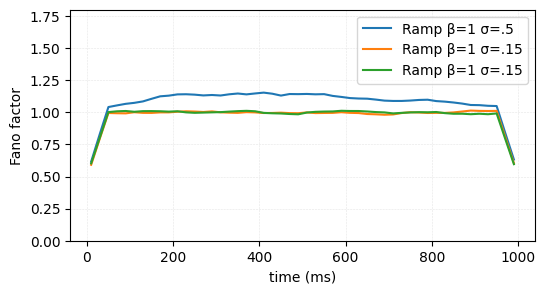

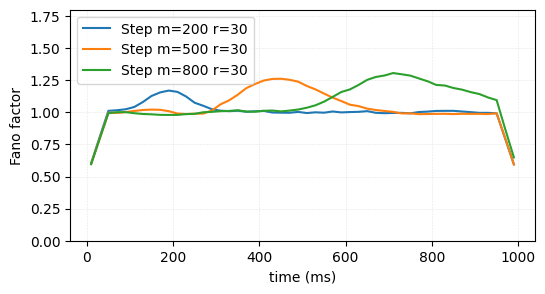

In [13]:
## generate smoothed plots
fig, ax3 = plt.subplots(figsize=(6,3))
fig, ax4 = plt.subplots(figsize=(6,3))

times, fano = dv.fano_factor(models.RampModel(beta=1, sigma=.5), ax=ax3,
            n_trials=5000, bin_width=20, smooth_ms=100, label="Ramp β=1 σ=.5")
dv.fano_factor(models.RampModel(beta=3, sigma=.15), ax=ax3,
            n_trials=5000, bin_width=20, smooth_ms=100, label="Ramp β=1 σ=.15")
dv.fano_factor(models.RampModel(beta=3, sigma=.15), ax=ax3,
            n_trials=5000, bin_width=20, smooth_ms=100, label="Ramp β=1 σ=.15")
dv.fano_factor(models.StepModel(m=200, r=30), ax=ax4,
            n_trials=5000, bin_width=20, smooth_ms=100, label="Step m=200 r=30")
dv.fano_factor(models.StepModel(m=500, r=30), ax=ax4,
            n_trials=5000, bin_width=20, smooth_ms=100, label="Step m=500 r=30")
dv.fano_factor(models.StepModel(m=800, r=30), ax=ax4,
            n_trials=5000, bin_width=20, smooth_ms=100, label="Step m=800 r=30")
 
ax3.legend()
ax4.legend()
plt.show()

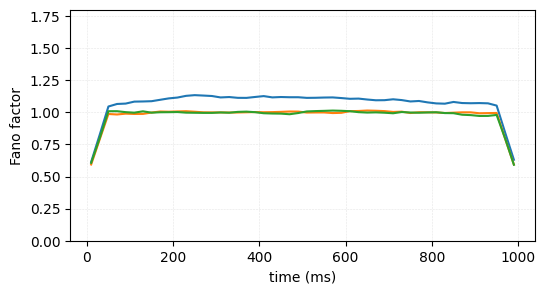

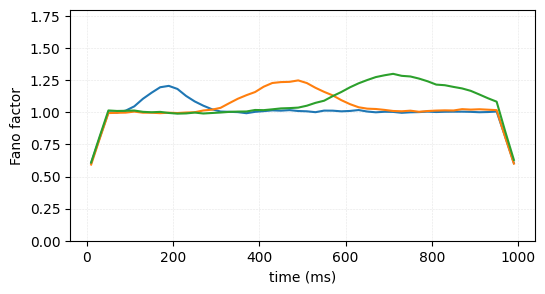

In [ ]:
fig, ax3 = plt.subplots(figsize=(6,3))
fig, ax4 = plt.subplots(figsize=(6,3))
fanos = np.zeros((6, 50))
times, fanos[0, :] = dv.fano_factor(models.RampModel(beta=1, sigma=.5), ax=ax3,
            n_trials=5000, bin_width=20, smooth_ms=100, label="Ramp β=1 σ=.5")
times, fanos[1, :] = dv.fano_factor(models.RampModel(beta=3, sigma=.15), ax=ax3,
            n_trials=5000, bin_width=20, smooth_ms=100, label="Ramp β=1 σ=.15")
times, fanos[2, :] = dv.fano_factor(models.RampModel(beta=3, sigma=.15), ax=ax3,
            n_trials=5000, bin_width=20, smooth_ms=100, label="Ramp β=1 σ=.15")
times, fanos[3, :] = dv.fano_factor(models.StepModel(m=200, r=30), ax=ax4,
            n_trials=5000, bin_width=20, smooth_ms=100, label="Step m=200 r=30")
times, fanos[4, :] = dv.fano_factor(models.StepModel(m=500, r=30), ax=ax4,
            n_trials=5000, bin_width=20, smooth_ms=100, label="Step m=500 r=30")
times, fanos[5, :] = dv.fano_factor(models.StepModel(m=800, r=30), ax=ax4,
            n_trials=5000, bin_width=20, smooth_ms=100, label="Step m=800 r=30")
 

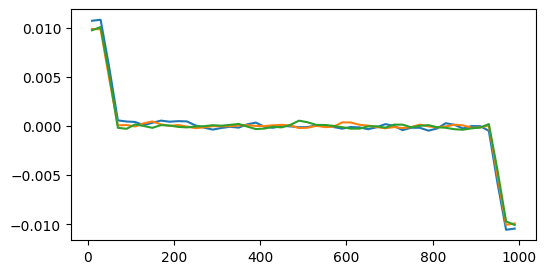

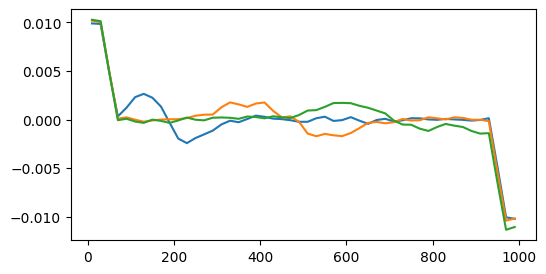

In [ ]:
# plot numerical derivatives of fano factor wrt time
gradients = [np.gradient(fanos[i, :], times) for i in range(6)]

fig, ax5 = plt.subplots(figsize=(6,3))
fig, ax6 = plt.subplots(figsize=(6,3))

for i in range(3):
    ax5.plot(times, gradients[i])

for j in range(3):
    ax6.plot(times, gradients[j+3])


plt.show()

## Task 1.4.